In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# REINFORCE: one noisy update, one exact expectation

Day 19 · Chapter 12. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/12-language-generation-as-a-policy.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## Exercise 1: a rewarded answer can still lose probability

The three rewards are 0, 1, and 3. Predict whether reward 1 necessarily receives a positive gradient. Then compare automatic differentiation with p times reward-minus-expectation.


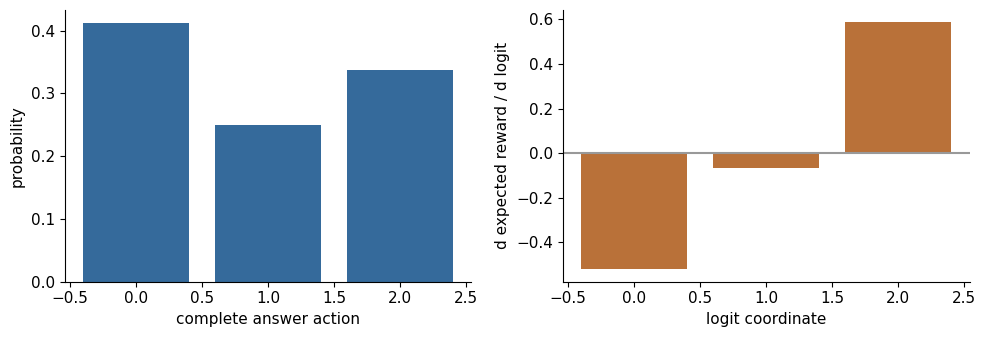

{'expected_reward': 1.2628423900178547, 'exact_gradient': [-0.5207036170854552, -0.06573393176389039, 0.5864375488493454]}


In [3]:
from dongxi_llms.policy_gradient_lab import exact_gradient,score_vectors,estimator_moments
logits=torch.tensor([.3,-.2,.1],dtype=torch.float64,requires_grad=True)
rewards=torch.tensor([0.,1.,3.],dtype=torch.float64)
p=logits.softmax(-1); objective=(p*rewards).sum()
autograd,=torch.autograd.grad(objective,logits)
analytic=exact_gradient(logits.detach(),rewards)
torch.testing.assert_close(autograd,analytic)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].bar(range(3),p.detach(),color=blue);axes[0].set(xlabel="complete answer action",ylabel="probability")
axes[1].bar(range(3),analytic,color=orange);axes[1].axhline(0,color=".6")
axes[1].set(xlabel="logit coordinate",ylabel="d expected reward / d logit")
plt.tight_layout();plt.show()
print({"expected_reward":float(objective.detach()),"exact_gradient":analytic.tolist()})


![Saved reference plot for 01 exact reinforce gradient, figure 1](../figures/chapter-12/day-19-01_exact_reinforce_gradient-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** reward is interpreted relative to the policy's expected reward. The optimizer maximizes the expectation, so gradient ascent decreases a below-average action even when its absolute reward is positive.

## Exercise 2: sample-gradient distribution

Can a sample point away from the exact expectation? Predict which action gives a large update. Enumerate rather than relying on one Monte Carlo batch.


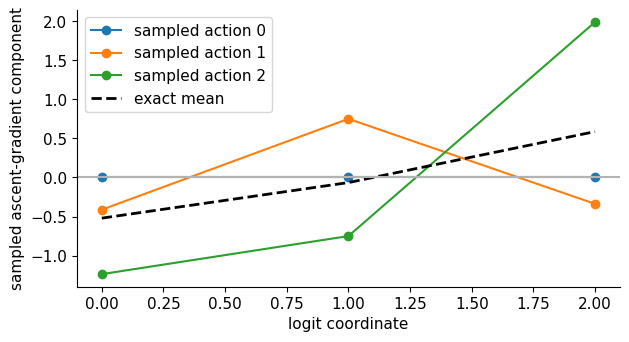

Exact unbaselined covariance trace: 1.6320410932074991


In [4]:
scores=score_vectors(p.detach())
samples=rewards[:,None]*scores
weighted=(p.detach()[:,None]*samples).sum(0)
torch.testing.assert_close(weighted,analytic)
fig,ax=plt.subplots(figsize=(7,3.6))
for action in range(3):ax.plot(range(3),samples[action],marker="o",label=f"sampled action {action}")
ax.plot(range(3),analytic,"k--",lw=2,label="exact mean")
ax.axhline(0,color=".7");ax.set(xlabel="logit coordinate",ylabel="sampled ascent-gradient component")
ax.legend();plt.show()
print("Exact unbaselined covariance trace:",estimator_moments(logits.detach(),rewards)["variance_trace"])


![Saved reference plot for 01 exact reinforce gradient, figure 2](../figures/chapter-12/day-19-01_exact_reinforce_gradient-02.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Read the figure:** each solid line is one possible sampled gradient, and the dashed line is its probability-weighted mean. Unbiasedness is a statement about the mean, not a guarantee about each update.

## Exercise 3: implement the sign and detachment contract

If action 2 receives reward 3, should the minimized loss be plus or minus reward times log-probability?


In [5]:
sample_logit=torch.tensor([.3,-.2,.1],dtype=torch.float64,requires_grad=True)
action=2
sample_reward=rewards[action].detach()
loss=-sample_reward*sample_logit.log_softmax(-1)[action]
loss.backward()
torch.testing.assert_close(-sample_logit.grad,samples[action])
offset_gradient=exact_gradient(logits.detach(),rewards+100)
torch.testing.assert_close(offset_gradient,analytic)
print("Loss gradient is the negative of the sampled ascent direction.")


Loss gradient is the negative of the sampled ascent direction.


**Solution:** use negative detached reward times sampled sequence log-probability. Adding a constant reward preserves the exact expected gradient but can change sample variance. For multi-token trajectories, sum log-probabilities; no derivative passes through discrete sampled token IDs. A policy-dependent reward needs a fresh derivation.
